# Пространственное неравенство

In [2]:
# import osmnx as ox
import warnings
import sys
import os

import requests
import geopandas as gpd
import pandas as pd
from popframe.models.region import Region

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')


## Подготовка данных

In [ ]:
import requests
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

def preprocess_data(region_id: int, level: int = None) -> gpd.GeoDataFrame:
    """
    Загружает оценки неравенства для всех соцгрупп, вычисляет итоговое
    Пространственное неравенство, подтягивает название и население
    территорий и возвращает итоговый GeoDataFrame.

    Параметры:
        region_id (int): ID региона для запроса оценок.
        level (int, optional): Уровень агрегирования для запроса. По умолчанию None.

    Возвращает:
        GeoDataFrame с колонками:
            - territory_id
            - geometry
            - для каждой соцгруппы: "{name} - Неравенство", "{name} - Неравенство - basic",
              "{name} - Неравенство - additional", "{name} - Неравенство - comfort"
            - "Пространственное неравенство"
            - name (название территории)
            - population (население)
    """
    API_URL = "http://10.32.1.102:5510/provision/{region_id}/get_evaluation"
    URBAN_API = "http://10.32.1.107:5300"
    POP_INDICATOR = 1

    # Список соц‑групп
    social_groups = [
        {"soc_group_id": 1,  "name": "Подростки младшего возраста (14-15)"},
        {"soc_group_id": 2,  "name": "Подростки старшего возраста (16-17)"},
        {"soc_group_id": 3,  "name": "Трудоспособные горожане (18-59)"},
        {"soc_group_id": 4,  "name": "Люди старшего возраста (60-75)"},
        {"soc_group_id": 5,  "name": "Люди преклонного возраста (старше 75)"},
        {"soc_group_id": 6,  "name": "Горожане, ожидающие ребенка"},
        {"soc_group_id": 7,  "name": "Горожане с младенцами"},
        {"soc_group_id": 8,  "name": "Горожане с детьми детсадовского возраста (1-6 лет)"},
        {"soc_group_id": 9,  "name": "Горожане с детьми младшего школьного возраста (7-13 лет)"},
        {"soc_group_id": 10, "name": "Горожане с подростками (14-18 лет)"},
        {"soc_group_id": 11, "name": "Христиане"},
        {"soc_group_id": 12, "name": "Мусульмане"},
        {"soc_group_id": 13, "name": "Иудеи"},
        {"soc_group_id": 14, "name": "Буддисты"},
        {"soc_group_id": 15, "name": "Студенты и учащиеся колледжей"},
        {"soc_group_id": 16, "name": "Горожане с питомцами"},
    ]

    def fetch_gdf(social_group_id: int) -> gpd.GeoDataFrame:
        params = {"region_id": region_id, "level": level, "social_group_id": social_group_id}
        resp = requests.get(API_URL.format(region_id=region_id), params=params)
        resp.raise_for_status()
        data = resp.json()
        gdf = gpd.GeoDataFrame.from_features(data["features"])
        return gdf.set_crs(4326).to_crs(32636)

    def fetch_territories(parent_id: int) -> gpd.GeoDataFrame:
        params = {
            'parent_id': parent_id,
            'get_all_levels': True,
            'cities_only': True,
            'centers_only': True
        }
        resp = requests.get(f"{URBAN_API}/api/v1/all_territories", params=params)
        resp.raise_for_status()
        return gpd.GeoDataFrame.from_features(resp.json()['features']).set_crs(4326)

    def get_population(terr_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        resp = requests.get(f"{URBAN_API}/api/v1/indicator/{POP_INDICATOR}/values", verify=False)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
        df['territory_id'] = df['territory'].apply(lambda x: x['id'] if isinstance(x, dict) else None)
        pop = df.groupby('territory_id')['value'].last().reset_index().rename(columns={'value': 'population'})
        terr_gdf = terr_gdf.rename_axis('idx').reset_index()
        terr_gdf = terr_gdf.merge(pop, on='territory_id', how='left')
        terr_gdf['population'] = terr_gdf['population'].fillna(0)
        return terr_gdf.set_index('idx')

    # 1) Базовая таблица
    first = social_groups[0]
    gdf_base = fetch_gdf(first["soc_group_id"])
    gdf_final = gdf_base[['territory_id', 'geometry']].copy()
    metrics = ["Обеспеченность", "basic", "additional", "comfort"]

    # 2) Делаем merge для всех соц‑групп
    for grp in tqdm(social_groups, desc="Обработка соц-групп"):
        gdf_i = fetch_gdf(grp["soc_group_id"])
        df_i = gdf_i[['territory_id'] + metrics].rename(columns={
            "Обеспеченность":            f"{grp['name']} - Неравенство",
            "basic":                     f"{grp['name']} - Неравенство - basic",
            "additional":                f"{grp['name']} - Неравенство - additional",
            "comfort":                   f"{grp['name']} - Неравенство - comfort",
        })
        gdf_final = gdf_final.merge(df_i, on='territory_id', how='left')

    # 3) Инвертируем (1 - value) для всех Неравенство-столбцов
    ine_cols = [c for c in gdf_final.columns if "Неравенство" in c]
    gdf_final[ine_cols] = 1 - gdf_final[ine_cols]

    # 4) Итоговое Пространственное неравенство
    gdf_final["Пространственное неравенство"] = gdf_final[ine_cols].mean(axis=1).round(2)

    # 5) Подтягиваем name и population
    terrs = fetch_territories(parent_id=region_id)
    terrs = get_population(terrs)
    attrs = terrs[['territory_id', 'name', 'population']]
    gdf_final = gdf_final.merge(attrs, on='territory_id', how='left')

    return gdf_final


In [4]:
gdf_final = preprocess_data(region_id=1, level=None)
gdf_final.head()


,territory_id,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population
0,207,POINT (542576.859 6580696.856),0.75,0.83,0.25,1.0,0.76,0.83,0.25,1.0,...,0.83,0.25,1.0,0.76,0.83,0.25,1.0,0.71,деревня Болото,10.0
1,208,POINT (544527.863 6593642.176),0.56,0.58,0.12,1.0,0.59,0.58,0.12,1.0,...,0.58,0.12,1.0,0.58,0.58,0.12,1.0,0.57,деревня Большой Остров,68.0
2,209,POINT (544980.557 6593207.96),0.41,0.33,0.12,1.0,0.44,0.33,0.12,1.0,...,0.33,0.12,1.0,0.42,0.33,0.12,1.0,0.47,деревня Бор,1734.0
3,210,POINT (543991.333 6589719.929),0.69,0.75,0.25,1.0,0.71,0.75,0.25,1.0,...,0.75,0.25,1.0,0.70,0.75,0.25,1.0,0.67,деревня Бороватое,10.0
4,211,POINT (538619.331 6577374.018),0.78,0.83,0.38,1.0,0.79,0.83,0.38,1.0,...,0.83,0.38,1.0,0.79,0.83,0.38,1.0,0.74,деревня Бочево,10.0


In [ ]:
# gdf_final.to_file('spatial_inequality_LO_towns.geojson')

## Тестовый пример

In [12]:
gdf_cities  = gpd.read_file('data/spatial_inequality_LO_towns.geojson')
gdf_cities.head(4)

,territory_id,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,Трудоспособные горожане (18-59) - Неравенство,...,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population,geometry
0,207,0.75,0.83,0.25,1.0,0.76,0.83,0.25,1.0,0.74,...,0.25,1.0,0.76,0.83,0.25,1.0,0.71,деревня Болото,10.0,POINT (542576.859 6580696.856)
1,208,0.56,0.58,0.12,1.0,0.59,0.58,0.12,1.0,0.59,...,0.12,1.0,0.58,0.58,0.12,1.0,0.57,деревня Большой Остров,68.0,POINT (544527.863 6593642.176)
2,209,0.41,0.33,0.12,1.0,0.44,0.33,0.12,1.0,0.46,...,0.12,1.0,0.42,0.33,0.12,1.0,0.47,деревня Бор,1734.0,POINT (544980.557 6593207.96)
3,210,0.69,0.75,0.25,1.0,0.71,0.75,0.25,1.0,0.69,...,0.25,1.0,0.70,0.75,0.25,1.0,0.67,деревня Бороватое,10.0,POINT (543991.333 6589719.929)


In [ ]:
gdf_agglomerations = gpd.read_file('data/settlement_boundaries.geojson')
gdf_agglomerations.head(5)

,anchor_name,geometry
0,город Приозерск,"POLYGON ((327427.183 6730670.252, 327136.101 6..."
1,город Луга,"POLYGON ((287016.41 6543947.996, 287016.796 65..."
2,город Сланцы,"POLYGON ((197917.925 6549729.864, 197918.01 65..."
3,город Ивангород,"POLYGON ((219178.207 6603388.048, 219177.62 66..."
4,город Волосово,"POLYGON ((277038.536 6568165.236, 277038.607 6..."
5,город Кингисепп,"POLYGON ((246661 6566351.854, 246660.44 656635..."
6,город Гатчина,"POLYGON ((317359.707 6634902.57, 317361.343 66..."
7,поселок Усть-Луга,"POLYGON ((212045.902 6628550.148, 212046.114 6..."
8,город Сосновый Бор,"POLYGON ((255514.928 6642291.912, 255517.745 6..."
9,город Приморск,"POLYGON ((246417.851 6702448.909, 246417.511 6..."


In [ ]:
# gdf_agglomerations = gpd.read_file('data/final_agglomerations.geojson')
# gdf_agglomerations

,type,core_cities,population,agglomeration_level,geometry
0,Polycentric,"Всеволожск, Сертолово, Новое Девяткино, Кудров...",1116875,4,"POLYGON ((310261.047 6587674.368, 310046.437 6..."
1,Polycentric,"Светогорск, Выборг",129217,1,"POLYGON ((264064.801 6702843.886, 263672.547 6..."
2,Monocentric,Сосновый бор,90865,1,"POLYGON ((267829.075 6613610.384, 267754.034 6..."
3,Polycentric,"Пикалево, Тихвин, Бокситогорск",105381,1,"POLYGON ((535225.286 6582852.229, 535504.813 6..."
4,Polycentric,"Кириши, Волхов",102494,1,"POLYGON ((421196.961 6582742.806, 421196.513 6..."
5,Polycentric,"Сланцы, Кингисепп",115479,1,"POLYGON ((206722.793 6553056.587, 206615.98 65..."
6,Monocentric,Луга,58784,1,"POLYGON ((306605.524 6486633.39, 306526.354 64..."
7,Polycentric,"Подпорожье, Лодейное Поле",44609,1,"POLYGON ((513102.444 6711145.664, 512912.14 67..."
8,Monocentric,Приозерск,30441,1,"POLYGON ((337963.013 6743785.69, 337736.871 67..."


In [14]:
from popframe.method.spatial_inequality import SpatialInequalityCalculator

region_model = Region.from_pickle('data/1.pickle')
calculator = SpatialInequalityCalculator(region=region_model)

## Пространственное неравенство для территорий (полигонов) по группам населения

In [15]:
# 3) Переносим метрики неравенства из городов на полигоны
gdf_polys_with_metrics, stats = calculator.transfer_inequality_metrics_to_polygons(
    gdf_cities,
    gdf_agglomerations,
    inequality_keyword="Неравенство"
)
stats

{'mean_within': {'Подростки младшего возраста (14-15) - Неравенство': 0.6338924731182796,
  'Подростки младшего возраста (14-15) - Неравенство - basic': 0.6906967741935484,
  'Подростки младшего возраста (14-15) - Неравенство - additional': 0.3650924731182796,
  'Подростки младшего возраста (14-15) - Неравенство - comfort': 0.8671225806451612,
  'Подростки старшего возраста (16-17) - Неравенство': 0.6455698924731182,
  'Подростки старшего возраста (16-17) - Неравенство - basic': 0.6906967741935484,
  'Подростки старшего возраста (16-17) - Неравенство - additional': 0.3650924731182796,
  'Подростки старшего возраста (16-17) - Неравенство - comfort': 0.8377763440860215,
  'Трудоспособные горожане (18-59) - Неравенство': 0.6255053763440861,
  'Трудоспособные горожане (18-59) - Неравенство - basic': 0.639247311827957,
  'Трудоспособные горожане (18-59) - Неравенство - additional': 0.4478236559139785,
  'Трудоспособные горожане (18-59) - Неравенство - comfort': 0.7209247311827958,
  'Люди с

In [16]:
gdf_polys_with_metrics.head(3)

,anchor_name,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Буддисты - Неравенство - comfort,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство
poly_index,,,,,,,,,,,,,,,,,,,,,
0,город Приозерск,"POLYGON ((327427.183 6730670.252, 327136.101 6...",0.532121,0.583939,0.296212,0.913333,0.559394,0.583939,0.296212,0.926515,...,0.913333,0.545758,0.583939,0.296212,0.926515,0.545758,0.583939,0.296212,0.913333,0.577424
1,город Луга,"POLYGON ((287016.41 6543947.996, 287016.796 65...",0.647885,0.731630,0.351894,0.804317,0.669031,0.731630,0.351894,0.833700,...,0.804317,0.660617,0.731630,0.351894,0.833700,0.660573,0.731630,0.351894,0.804317,0.631057
2,город Сланцы,"POLYGON ((197917.925 6549729.864, 197918.01 65...",0.797669,0.800902,0.706391,0.827068,0.799398,0.800902,0.706391,0.853158,...,0.827068,0.804135,0.800902,0.706391,0.853158,0.804135,0.800902,0.706391,0.827068,0.778872


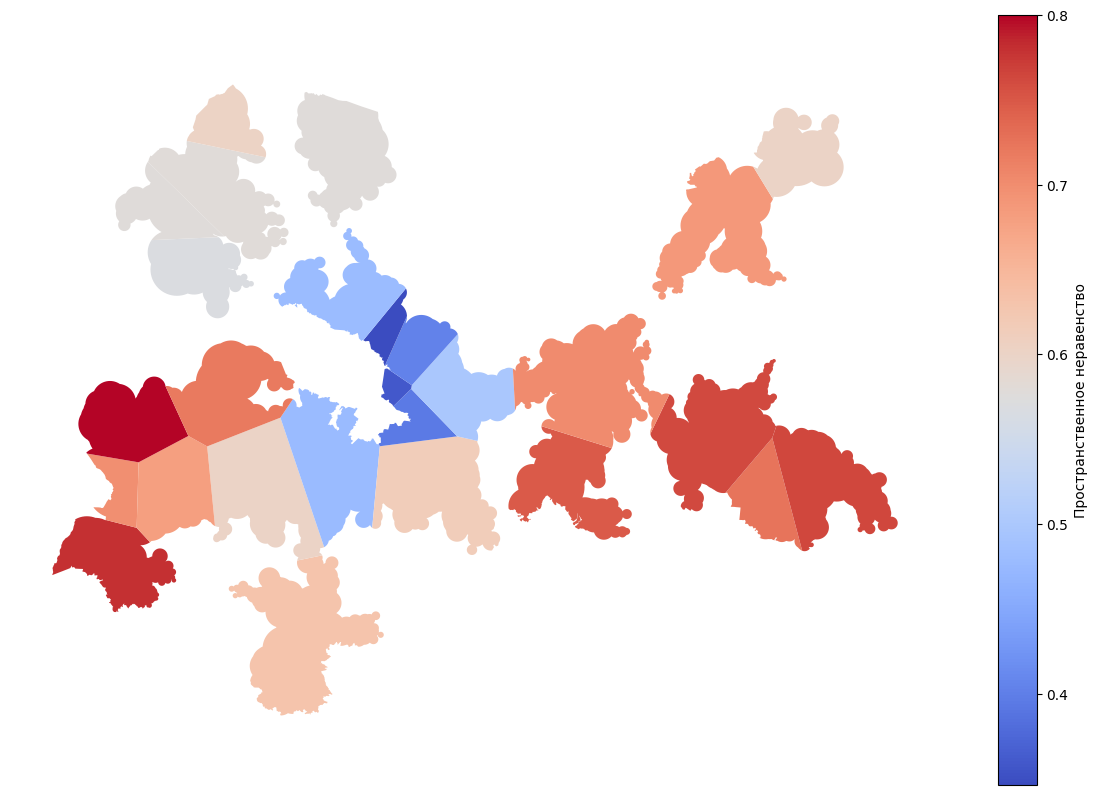

In [17]:
gdf_polys_with_metrics.plot(
    column='Пространственное неравенство',
    cmap='coolwarm',
    legend=True,
    figsize=(15, 10),
    legend_kwds={'label': "Пространственное неравенство"},
).set_axis_off()

## Лучшие территории по наименьшему неравенству

In [18]:
best_youth = calculator.get_best_territory(
    gdf_polys_with_metrics,
    group_name="Подростки младшего возраста (14-15)",
    top_n= 3 # опционально, сколько лучших территорий показать (по умолчанию 5)
)
best_youth

,anchor_name,geometry,Пространственное неравенство,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort
poly_index,,,,,,,
24,город Мурино,"POLYGON ((351375.352 6664593.09, 351374.724 66...",0.346316,0.301579,0.324211,0.140526,0.635789
20,город Кудрово,"POLYGON ((359656.173 6637951.473, 359656.203 6...",0.359231,0.363462,0.343077,0.000000,0.793846
18,город Отрадное,"POLYGON ((358256.176 6613983.925, 358256.291 6...",0.395714,0.401071,0.368571,0.081429,0.768571


In [19]:
# 5) Находим территорию с минимальным общим неравенством
best_overall = calculator.get_best_territory(
    gdf_cities)
best_overall

,territory_id,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,Трудоспособные горожане (18-59) - Неравенство,...,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population,geometry
1060,1267,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,город Сосновый Бор,63462.0,POINT (283470.037 6644117.652)
1585,1792,0.22,0.25,0.00,0.20,0.24,0.25,0.00,0.17,0.23,...,0.00,0.17,0.24,0.25,0.00,0.20,0.16,деревня Шереметьевка,44.0,POINT (389284.621 6648362.546)
2621,2828,0.19,0.17,0.12,0.20,0.24,0.17,0.12,0.33,0.23,...,0.12,0.33,0.21,0.17,0.12,0.20,0.17,деревня Фишева Гора,5.0,POINT (530645.861 6611990.519)
1651,1858,0.16,0.23,0.12,0.25,0.21,0.23,0.12,0.38,0.18,...,0.12,0.38,0.18,0.23,0.12,0.25,0.19,деревня Энколово,412.0,POINT (356965.492 6666121.124)
1654,1861,0.16,0.25,0.12,0.20,0.21,0.25,0.12,0.33,0.18,...,0.12,0.33,0.18,0.25,0.12,0.20,0.19,деревня Корабсельки,200.0,POINT (355472.818 6665585.5)


## Соц. группа с наименьшим неравенством

In [20]:

gdf_with_best_group = calculator.get_best_group_for_territory(
    gdf_cities
)
gdf_with_best_group.head(3)

,territory_id,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,Трудоспособные горожане (18-59) - Неравенство,...,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,name,population,geometry,Наименьшее неравенство для соц‑группы
0,207,0.75,0.83,0.25,1.0,0.76,0.83,0.25,1.0,0.74,...,1.0,0.76,0.83,0.25,1.0,0.71,деревня Болото,10.0,POINT (542576.859 6580696.856),Люди преклонного возраста (старше 75)
1,208,0.56,0.58,0.12,1.0,0.59,0.58,0.12,1.0,0.59,...,1.0,0.58,0.58,0.12,1.0,0.57,деревня Большой Остров,68.0,POINT (544527.863 6593642.176),Подростки младшего возраста (14-15)
2,209,0.41,0.33,0.12,1.0,0.44,0.33,0.12,1.0,0.46,...,1.0,0.42,0.33,0.12,1.0,0.47,деревня Бор,1734.0,POINT (544980.557 6593207.96),Подростки младшего возраста (14-15)


In [21]:

gdf_with_best_group = calculator.get_best_group_for_territory(
    gdf_polys_with_metrics
)
gdf_with_best_group.head(3)

,anchor_name,geometry,Подростки младшего возраста (14-15) - Неравенство,Подростки младшего возраста (14-15) - Неравенство - basic,Подростки младшего возраста (14-15) - Неравенство - additional,Подростки младшего возраста (14-15) - Неравенство - comfort,Подростки старшего возраста (16-17) - Неравенство,Подростки старшего возраста (16-17) - Неравенство - basic,Подростки старшего возраста (16-17) - Неравенство - additional,Подростки старшего возраста (16-17) - Неравенство - comfort,...,Студенты и учащиеся колледжей - Неравенство,Студенты и учащиеся колледжей - Неравенство - basic,Студенты и учащиеся колледжей - Неравенство - additional,Студенты и учащиеся колледжей - Неравенство - comfort,Горожане с питомцами - Неравенство,Горожане с питомцами - Неравенство - basic,Горожане с питомцами - Неравенство - additional,Горожане с питомцами - Неравенство - comfort,Пространственное неравенство,Наименьшее неравенство для соц‑группы
poly_index,,,,,,,,,,,,,,,,,,,,,
0,город Приозерск,"POLYGON ((327427.183 6730670.252, 327136.101 6...",0.532121,0.583939,0.296212,0.913333,0.559394,0.583939,0.296212,0.926515,...,0.545758,0.583939,0.296212,0.926515,0.545758,0.583939,0.296212,0.913333,0.577424,Люди преклонного возраста (старше 75)
1,город Луга,"POLYGON ((287016.41 6543947.996, 287016.796 65...",0.647885,0.731630,0.351894,0.804317,0.669031,0.731630,0.351894,0.833700,...,0.660617,0.731630,0.351894,0.833700,0.660573,0.731630,0.351894,0.804317,0.631057,Люди преклонного возраста (старше 75)
2,город Сланцы,"POLYGON ((197917.925 6549729.864, 197918.01 65...",0.797669,0.800902,0.706391,0.827068,0.799398,0.800902,0.706391,0.853158,...,0.804135,0.800902,0.706391,0.853158,0.804135,0.800902,0.706391,0.827068,0.778872,Люди старшего возраста (60-75)
